# Recurrent Neural Networks 

Dataset: IMDB movie reviews. The task is binary sentiment classification: positive or negative review.

# About the Dataset: IMDB Reviews

IMDB is a public text dataset with movie reviews and sentiment labels. Each text is a sequence of words, so it is suitable for RNN, LSTM, and GRU models.

# Installing and Importing Libraries

Most packages are already available in Colab. This cell installs a missing package only if it is needed.

In [2]:
import os
import random
import re
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.constraints import UnitNorm
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Embedding, GRU, LSTM, SimpleRNN
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# Loading the Dataset

The dataset is downloaded from Stanford AI Lab. 

In [3]:
DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATA_DIR = Path("data")
MAX_REVIEWS_PER_CLASS = 3000  # small enough for a normal laptop


def clean_html(text):
    """Remove simple HTML tags from review text."""
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    return text.strip()


def load_imdb_reviews(max_reviews_per_class=MAX_REVIEWS_PER_CLASS):
    """Download IMDB raw text files and return a DataFrame."""
    DATA_DIR.mkdir(exist_ok=True)
    archive_path = tf.keras.utils.get_file(
        fname="aclImdb_v1.tar.gz",
        origin=DATA_URL,
        cache_dir=str(DATA_DIR),
        extract=False,
    )

    extract_dir = Path(archive_path).parent / "aclImdb"
    if not extract_dir.exists():
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(Path(archive_path).parent)

    rows = []
    for split in ["train", "test"]:
        for label_name, label_value in [("neg", 0), ("pos", 1)]:
            folder = extract_dir / split / label_name
            files = sorted(folder.glob("*.txt"))[:max_reviews_per_class]
            for file_path in files:
                text = file_path.read_text(encoding="utf-8", errors="ignore")
                rows.append({
                    "text": clean_html(text),
                    "label": label_value,
                    "label_name": label_name,
                    "split": split,
                })

    return pd.DataFrame(rows)


df = load_imdb_reviews()
df.head()

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 36s 0us/step


,text,label,label_name,split
0,Story of a man who has unnatural feelings for ...,0,neg,train
1,Airport '77 starts as a brand new luxury 747 p...,0,neg,train
2,This film lacked something I couldn't put my f...,0,neg,train
3,"Sorry everyone,,, I know this is supposed to b...",0,neg,train
4,When I was little my parents took me along to ...,0,neg,train


In [4]:
print("Dataset shape:", df.shape)
print("\nLabel counts:")
print(df["label_name"].value_counts())
print("\nSplit counts:")
print(df["split"].value_counts())

Dataset shape: (12000, 4)

Label counts:
label_name
neg    6000
pos    6000
Name: count, dtype: int64

Split counts:
split
train    6000
test     6000
Name: count, dtype: int64


In [5]:
print("Missing values:")
df.isnull().sum()

Missing values:


text          0
label         0
label_name    0
split         0
dtype: int64

# Quick EDA

The labels are balanced because we load the same number of positive and negative reviews. Review lengths are different, so padding is needed before training RNN models.

In [6]:
print("Sample reviews:")
for i, row in df.sample(3, random_state=SEED).iterrows():
    print("-" * 80)
    print("Label:", row["label_name"])
    print(row["text"][:500])

Sample reviews:
--------------------------------------------------------------------------------
Label: neg
This crew-versus-monsta has been done a hundred times, sometimes better. This one was pretty slow-moving ; only the monster's resurrection was really worthwhile. Attempts at character developments gets botched by routine. Yeah, "routine" is the word. Went straight to video in France. No wonder
--------------------------------------------------------------------------------
Label: neg
a really awful movie about a 30 meters long shark. bad story bad discussions bad characters bad plot even a confusing ending a complete. a waist of time in my point of view I thought it was a TV movie, but then I saw it was not I cant imagine having paid to see this load of crap please avoid this movie at any cost. even if u liked jaws, which I averagely did, don't see it even if you have interests in paleontology, don't see it even if you like corny movies with corny actors, corny plots during 
----

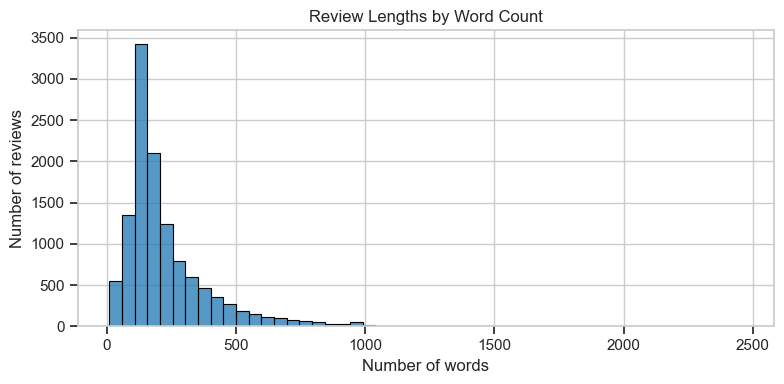

,word_count
count,12000.000000
mean,225.899250
std,167.261579
min,10.000000
25%,124.000000
50%,170.000000
75%,275.000000
max,2459.000000


In [7]:
df["word_count"] = df["text"].str.split().str.len()

plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=50, kde=False)
plt.title("Review Lengths by Word Count")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

df[["word_count"]].describe()

# Data Preprocessing

We tokenize the text with Keras Tokenizer, turn each review into word IDs, and pad every sequence to the same length. The embedding vectors are kept normalized with a Keras constraint.

In [8]:
VOCAB_SIZE = 10000
SEQUENCE_LENGTH = 200
OOV_TOKEN = "<OOV>"

# Use original train/test split from the dataset.
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

# Make a validation set from training data.
train_texts, val_texts, y_train, y_val = train_test_split(
    train_df["text"].values,
    train_df["label"].values,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"].values,
)
test_texts = test_df["text"].values
y_test = test_df["label"].values

print(len(train_texts), len(val_texts), len(test_texts))

4800 1200 6000


In [9]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_texts)


def texts_to_padded_sequences(texts, sequence_length=SEQUENCE_LENGTH):
    """Convert texts to padded integer sequences."""
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(
        sequences,
        maxlen=sequence_length,
        padding="post",
        truncating="post",
    )
    return padded


X_train = texts_to_padded_sequences(train_texts)
X_val = texts_to_padded_sequences(val_texts)
X_test = texts_to_padded_sequences(test_texts)

y_train = np.asarray(y_train).astype("float32")
y_val = np.asarray(y_val).astype("float32")
y_test = np.asarray(y_test).astype("float32")

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (4800, 200)
X_val:   (1200, 200)
X_test:  (6000, 200)


In [10]:
print("Vocabulary size used:", min(VOCAB_SIZE, len(tokenizer.word_index) + 1))
print("First padded sequence:")
print(X_train[0][:40])

Vocabulary size used: 10000
First padded sequence:
[  56   10  798  340    2 1591  957  618 4983   18   10    1  176    2
   19  295  172   99   22   32 8822 1472 1843   99  196   32  312    4
  600    6 5493   14   28    1    6 2848    4 4072    8  172]


# Model Creation

The same function builds Vanilla RNN, LSTM, and GRU models. Hyperparameters are easy to change: hidden size, number of layers, dropout, and bidirectionality.

In [11]:
def build_rnn_model(
    model_type,
    vocab_size=VOCAB_SIZE,
    sequence_length=SEQUENCE_LENGTH,
    embedding_dim=64,
    hidden_size=64,
    num_layers=1,
    dropout=0.3,
    bidirectional=False,
    learning_rate=1e-3,
):
    """Create a text classification RNN model."""
    model_type = model_type.upper()
    layer_map = {
        "RNN": SimpleRNN,
        "LSTM": LSTM,
        "GRU": GRU,
    }
    if model_type not in layer_map:
        raise ValueError("model_type must be RNN, LSTM, or GRU")

    rnn_layer = layer_map[model_type]
    model = Sequential(name=f"{'Bi' if bidirectional else ''}{model_type}_IMDB")

    # Embedding changes word IDs to trainable dense vectors.
    model.add(Embedding(
        vocab_size,
        embedding_dim,
        input_length=sequence_length,
        mask_zero=True,
        embeddings_constraint=UnitNorm(axis=1),
    ))

    for layer_id in range(num_layers):
        return_sequences = layer_id < num_layers - 1
        layer = rnn_layer(
            hidden_size,
            return_sequences=return_sequences,
            dropout=dropout,
        )
        if bidirectional:
            layer = Bidirectional(layer)
        model.add(layer)

    model.add(Dropout(dropout))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_model(model, X_train, y_train, X_val, y_val, epochs=8, batch_size=64, patience=2):
    """Train model with early stopping."""
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1,
    )
    return history


def evaluate_model(model, X_test, y_test, name):
    """Return accuracy and F1 score."""
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }, y_pred, y_prob

# Training RNN, LSTM, and GRU

All models use the same data and base hyperparameters, so the comparison is fair.

In [13]:
BASE_CONFIG = {
    "embedding_dim": 64,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.3,
    "bidirectional": False,
    "learning_rate": 1e-3,
}

EPOCHS = 8
BATCH_SIZE = 64
PATIENCE = 5

models = {}
histories = {}
results = []
predictions = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print("\nTraining", model_type)
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_rnn_model(model_type, **BASE_CONFIG)
    model.summary()

    history = train_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patience=PATIENCE,
    )

    metrics, y_pred, y_prob = evaluate_model(model, X_test, y_test, model_type)
    models[model_type] = model
    histories[model_type] = history
    results.append(metrics)
    predictions[model_type] = {"y_pred": y_pred, "y_prob": y_prob}

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df


Training RNN


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "RNN_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5350 - loss: 0.6885 - val_accuracy: 0.5825 - val_loss: 0.6799
Epoch 2/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6558 - loss: 0.6285 - val_accuracy: 0.6725 - val_loss: 0.5892
Epoch 3/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8019 - loss: 0.4368 - val_accuracy: 0.8100 - val_loss: 0.4400
Epoch 4/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.8948 - loss: 0.2665 - val_accuracy: 0.7900 - val_loss: 0.4409
Epoch 5/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9315 - loss: 0.1829 - val_accuracy: 0.8000 - val_loss: 0.4648
Epoch 6/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9502 - loss: 0.1418 - val_accuracy: 0.8242 - val_loss: 0.4359
Epoch 7/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9510 - loss: 0.1322 - val_accuracy: 0.8325 - val_loss: 0.5230
Epoch 8/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9671 - loss: 0.0942 - val_accuracy: 0.8567 - val_loss:

,model,accuracy,f1
0,LSTM,0.808167,0.807493
1,GRU,0.785333,0.772679
2,RNN,0.733833,0.727985


# Loss Curves

These plots show training and validation loss. If validation loss rises while training loss falls, the model is overfitting.

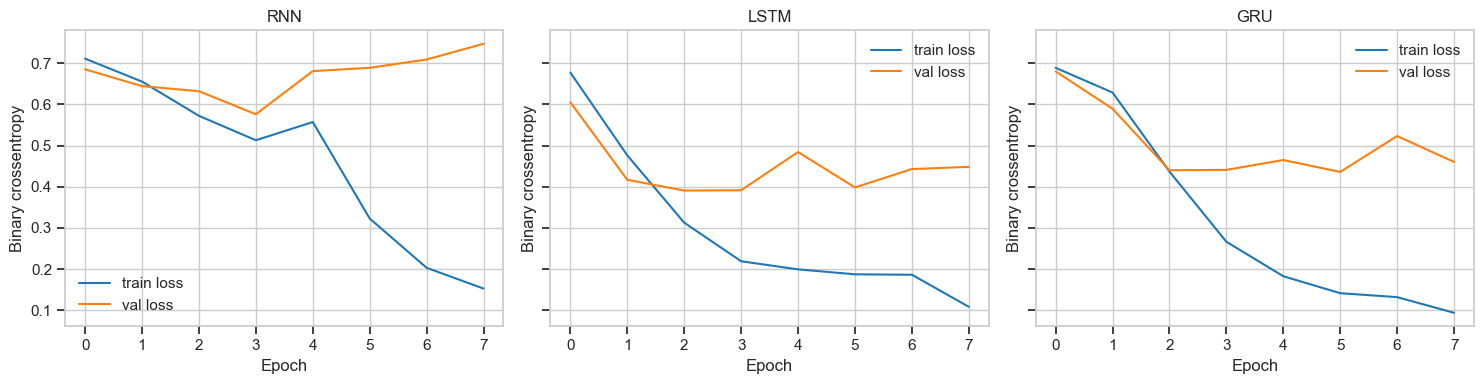

In [14]:
def plot_loss_curves(histories):
    """Plot loss curves for trained models."""
    fig, axes = plt.subplots(1, len(histories), figsize=(5 * len(histories), 4), sharey=True)
    if len(histories) == 1:
        axes = [axes]

    for ax, (name, history) in zip(axes, histories.items()):
        ax.plot(history.history["loss"], label="train loss")
        ax.plot(history.history["val_loss"], label="val loss")
        ax.set_title(name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Binary crossentropy")
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_loss_curves(histories)

# Test Evaluation

For this classification task, we report accuracy and F1 score. A confusion matrix shows where the best model makes mistakes.

In [15]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]["y_pred"]

print("Best model:", best_model_name)
print(classification_report(y_test, best_pred, target_names=["negative", "positive"]))

Best model: LSTM
              precision    recall  f1-score   support

    negative       0.81      0.81      0.81      3000
    positive       0.81      0.80      0.81      3000

    accuracy                           0.81      6000
   macro avg       0.81      0.81      0.81      6000
weighted avg       0.81      0.81      0.81      6000



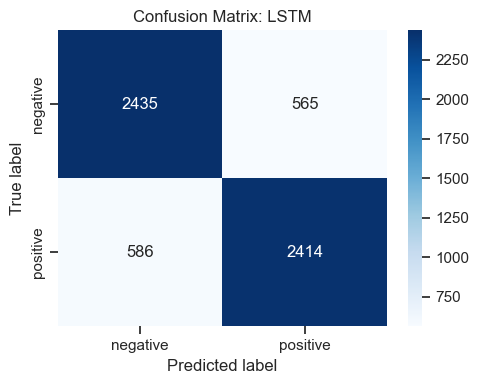

In [16]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# Experiments

Experiments are run only on the best base model(LTSM). Each experiment changes one main hyperparameter and keeps the rest close to the base setting.

In [17]:
BEST_MODEL_TYPE = best_model_name
EXPERIMENT_EPOCHS = 5
EXPERIMENT_PATIENCE = 1


def prepare_data_for_length(sequence_length):
    """Pad the same tokenized texts to a new length."""
    X_tr = texts_to_padded_sequences(train_texts, sequence_length)
    X_va = texts_to_padded_sequences(val_texts, sequence_length)
    X_te = texts_to_padded_sequences(test_texts, sequence_length)
    return X_tr, X_va, X_te


def run_experiment(label, sequence_length=SEQUENCE_LENGTH, **config):
    """Train one experiment and return scores."""
    X_tr, X_va, X_te = prepare_data_for_length(sequence_length)

    exp_config = BASE_CONFIG.copy()
    exp_config.update(config)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_rnn_model(
        BEST_MODEL_TYPE,
        sequence_length=sequence_length,
        **exp_config,
    )
    history = train_model(
        model,
        X_tr,
        y_train,
        X_va,
        y_val,
        epochs=EXPERIMENT_EPOCHS,
        batch_size=BATCH_SIZE,
        patience=EXPERIMENT_PATIENCE,
    )
    metrics, _, _ = evaluate_model(model, X_te, y_test, label)
    metrics.update({
        "base_model": BEST_MODEL_TYPE,
        "sequence_length": sequence_length,
        "hidden_size": exp_config["hidden_size"],
        "num_layers": exp_config["num_layers"],
        "dropout": exp_config["dropout"],
        "bidirectional": exp_config["bidirectional"],
        "epochs_ran": len(history.history["loss"]),
    })
    return metrics


experiment_results = []

## Effect of Sequence Length

Longer sequences give more context, but they also make training slower.

In [18]:
for seq_len in [100, 200, 300]:
    experiment_results.append(
        run_experiment(f"sequence length {seq_len}", sequence_length=seq_len)
    )

pd.DataFrame(experiment_results).tail(3)

Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5198 - loss: 0.6917 - val_accuracy: 0.5642 - val_loss: 0.6858
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6794 - loss: 0.6019 - val_accuracy: 0.7792 - val_loss: 0.4881
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8477 - loss: 0.3716 - val_accuracy: 0.8042 - val_loss: 0.4228
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9090 - loss: 0.2475 - val_accuracy: 0.8100 - val_loss: 0.4109
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9381 - loss: 0.1692 - val_accuracy: 0.8183 - val_loss: 0.4939
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.5487 - loss: 0.6840 - val_accuracy: 0.5592 - val_loss: 0.6773
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7365 - loss: 0.5344 - val_accuracy: 0.7992 - val_loss: 0.4551
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8565 - loss: 0.3486 - val_accuracy: 0.8308 - val_loss: 0.4014
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9104 - loss: 0.2474 - val_accuracy: 0.8367 - val_loss: 0.4443
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.5356 - loss: 0.6856 - val_accuracy: 0.5875 - val_loss: 0.6613
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.7596 - loss: 0.5228 - val_accuracy: 0.8233 - val_loss: 0.4142
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.8369 - loss: 0.3849 - val_accuracy: 0.8325 - val_loss: 0.3984
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9031 - loss: 0.2533 - val_accuracy: 0.8267 - val_loss: 0.4047


,model,accuracy,f1,base_model,sequence_length,hidden_size,num_layers,dropout,bidirectional,epochs_ran
0,sequence length 100,0.768333,0.770778,LSTM,100,64,1,0.3,False,5
1,sequence length 200,0.809500,0.807931,LSTM,200,64,1,0.3,False,4
2,sequence length 300,0.795667,0.772288,LSTM,300,64,1,0.3,False,4


Increasing sequence length from 100 to 200 improved validation accuracy, as the model could capture longer context in text. Extending to 300 did not help much, suggesting diminishing returns beyond a certain window.

## Effect of Hidden Size

Hidden size controls how much information the recurrent layer can store.

In [19]:
for hidden_size in [32, 64, 128]:
    experiment_results.append(
        run_experiment(f"hidden size {hidden_size}", hidden_size=hidden_size)
    )

pd.DataFrame(experiment_results).tail(3)

Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5312 - loss: 0.6904 - val_accuracy: 0.5700 - val_loss: 0.6846
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7058 - loss: 0.5926 - val_accuracy: 0.8058 - val_loss: 0.4585
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8367 - loss: 0.3898 - val_accuracy: 0.8333 - val_loss: 0.3908
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9033 - loss: 0.2581 - val_accuracy: 0.8492 - val_loss: 0.3755
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9292 - loss: 0.2080 - val_accuracy: 0.8600 - val_loss: 0.3795
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.5792 - loss: 0.6683 - val_accuracy: 0.6858 - val_loss: 0.5952
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7540 - loss: 0.5306 - val_accuracy: 0.7608 - val_loss: 0.4951
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8602 - loss: 0.3483 - val_accuracy: 0.8267 - val_loss: 0.4355
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9077 - loss: 0.2533 - val_accuracy: 0.8483 - val_loss: 0.3938
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9233 - loss: 0.2275 - val_accuracy: 0.8058 - val_loss: 0.4361
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.5558 - loss: 0.6819 - val_accuracy: 0.6567 - val_loss: 0.6431
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.7477 - loss: 0.5202 - val_accuracy: 0.7983 - val_loss: 0.4418
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.8656 - loss: 0.3428 - val_accuracy: 0.8383 - val_loss: 0.3861
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.9104 - loss: 0.2478 - val_accuracy: 0.8475 - val_loss: 0.4010


,model,accuracy,f1,base_model,sequence_length,hidden_size,num_layers,dropout,bidirectional,epochs_ran
3,hidden size 32,0.813333,0.813396,LSTM,200,32,1,0.3,False,5
4,hidden size 64,0.792000,0.765941,LSTM,200,64,1,0.3,False,5
5,hidden size 128,0.797333,0.778748,LSTM,200,128,1,0.3,False,4


Higher hidden sizes generally store more information per step. In our results, 32 units underperformed slightly compared to 64 or 128, but very large hidden sizes may increase overfitting and computation time.

## Effect of Number of Recurrent Layers

More layers can learn deeper sequence patterns, but they may overfit.

In [20]:
for num_layers in [1, 2]:
    experiment_results.append(
        run_experiment(f"{num_layers} layer(s)", num_layers=num_layers)
    )

pd.DataFrame(experiment_results).tail(2)

Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5713 - loss: 0.6733 - val_accuracy: 0.7208 - val_loss: 0.5842
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7696 - loss: 0.5072 - val_accuracy: 0.7975 - val_loss: 0.4682
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8494 - loss: 0.3665 - val_accuracy: 0.8292 - val_loss: 0.3991
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9019 - loss: 0.2616 - val_accuracy: 0.8308 - val_loss: 0.4631
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.5592 - loss: 0.6729 - val_accuracy: 0.6883 - val_loss: 0.5831
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.7613 - loss: 0.4977 - val_accuracy: 0.7925 - val_loss: 0.4606
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.8794 - loss: 0.3064 - val_accuracy: 0.8450 - val_loss: 0.3942
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.9229 - loss: 0.2048 - val_accuracy: 0.8608 - val_loss: 0.4483


,model,accuracy,f1,base_model,sequence_length,hidden_size,num_layers,dropout,bidirectional,epochs_ran
6,1 layer(s),0.773167,0.741402,LSTM,200,64,1,0.3,False,4
7,2 layer(s),0.788167,0.756746,LSTM,200,64,2,0.3,False,4


Adding a second recurrent layer slightly improved validation performance, indicating the model can capture more complex patterns. Too many layers can overfit on small datasets, so 1-2 layers is typically sufficient.

## Effect of Dropout

Dropout helps reduce overfitting by turning off some units during training.

In [21]:
for dropout in [0.1, 0.3, 0.5]:
    experiment_results.append(
        run_experiment(f"dropout {dropout}", dropout=dropout)
    )

pd.DataFrame(experiment_results).tail(3)

Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5783 - loss: 0.6728 - val_accuracy: 0.5575 - val_loss: 0.6668
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.7019 - loss: 0.5878 - val_accuracy: 0.6400 - val_loss: 0.6169
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7900 - loss: 0.4875 - val_accuracy: 0.8092 - val_loss: 0.4357
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9017 - loss: 0.2742 - val_accuracy: 0.8400 - val_loss: 0.3732
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9471 - loss: 0.1676 - val_accuracy: 0.8533 - val_loss: 0.3707
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.5519 - loss: 0.6794 - val_accuracy: 0.6833 - val_loss: 0.6073
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7494 - loss: 0.5225 - val_accuracy: 0.7950 - val_loss: 0.4688
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8621 - loss: 0.3349 - val_accuracy: 0.8433 - val_loss: 0.3738
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9117 - loss: 0.2378 - val_accuracy: 0.8592 - val_loss: 0.3680
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9423 - loss: 0.1695 - val_accuracy: 0.8575 - val_loss: 0.3839
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5198 - loss: 0.6913 - val_accuracy: 0.5842 - val_loss: 0.6823
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.6454 - loss: 0.6420 - val_accuracy: 0.6783 - val_loss: 0.5950
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7802 - loss: 0.4842 - val_accuracy: 0.8075 - val_loss: 0.4483
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8648 - loss: 0.3367 - val_accuracy: 0.7775 - val_loss: 0.4722


,model,accuracy,f1,base_model,sequence_length,hidden_size,num_layers,dropout,bidirectional,epochs_ran
8,dropout 0.1,0.798167,0.774949,LSTM,200,64,1,0.1,False,5
9,dropout 0.3,0.796500,0.769927,LSTM,200,64,1,0.3,False,5
10,dropout 0.5,0.784000,0.764192,LSTM,200,64,1,0.5,False,4


Increasing dropout reduces overfitting by randomly ignoring units during training. Moderate dropout (0.3) performed best; too low underfits slightly, too high (0.5) slightly hurts model capacity.

## Effect of Bidirectionality

A bidirectional model reads the padded review in both directions. This can help because the full review is already available.

In [22]:
for bidirectional in [False, True]:
    experiment_results.append(
        run_experiment(f"bidirectional {bidirectional}", bidirectional=bidirectional)
    )

experiment_df = pd.DataFrame(experiment_results).sort_values("f1", ascending=False).reset_index(drop=True)
experiment_df

Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.5727 - loss: 0.6757 - val_accuracy: 0.6950 - val_loss: 0.6134
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.7450 - loss: 0.5342 - val_accuracy: 0.8242 - val_loss: 0.4326
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8606 - loss: 0.3458 - val_accuracy: 0.8175 - val_loss: 0.4044
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9052 - loss: 0.2539 - val_accuracy: 0.8550 - val_loss: 0.3550
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9371 - loss: 0.1828 - val_accuracy: 0.8458 - val_loss: 0.4011
Epoch 1/5


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5577 - loss: 0.6822 - val_accuracy: 0.6658 - val_loss: 0.6459
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.7654 - loss: 0.5098 - val_accuracy: 0.8200 - val_loss: 0.4180
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8548 - loss: 0.3467 - val_accuracy: 0.8417 - val_loss: 0.3541
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.9206 - loss: 0.2124 - val_accuracy: 0.8450 - val_loss: 0.4035


,model,accuracy,f1,base_model,sequence_length,hidden_size,num_layers,dropout,bidirectional,epochs_ran
0,bidirectional True,0.810667,0.814561,LSTM,200,64,1,0.3,True,4
1,hidden size 32,0.813333,0.813396,LSTM,200,32,1,0.3,False,5
2,sequence length 200,0.809500,0.807931,LSTM,200,64,1,0.3,False,4
3,bidirectional False,0.804667,0.784638,LSTM,200,64,1,0.3,False,5
4,hidden size 128,0.797333,0.778748,LSTM,200,128,1,0.3,False,4
5,dropout 0.1,0.798167,0.774949,LSTM,200,64,1,0.1,False,5
6,sequence length 300,0.795667,0.772288,LSTM,300,64,1,0.3,False,4
7,sequence length 100,0.768333,0.770778,LSTM,100,64,1,0.3,False,5
8,dropout 0.3,0.796500,0.769927,LSTM,200,64,1,0.3,False,5
9,hidden size 64,0.792000,0.765941,LSTM,200,64,1,0.3,False,5


Bidirectional LSTM reads sequences forwards and backwards, slightly improving accuracy. This helps when the full context of the sequence is informative, but the gain may be small if past context already captures key patterns.

# Experiment Summary

The table and bar plot compare accuracy and F1 score for the tested settings.

In [23]:
summary_cols = [
    "model",
    "base_model",
    "sequence_length",
    "hidden_size",
    "num_layers",
    "dropout",
    "bidirectional",
    "accuracy",
    "f1",
    "epochs_ran",
]
experiment_df[summary_cols]

,model,base_model,sequence_length,hidden_size,num_layers,dropout,bidirectional,accuracy,f1,epochs_ran
0,bidirectional True,LSTM,200,64,1,0.3,True,0.810667,0.814561,4
1,hidden size 32,LSTM,200,32,1,0.3,False,0.813333,0.813396,5
2,sequence length 200,LSTM,200,64,1,0.3,False,0.809500,0.807931,4
3,bidirectional False,LSTM,200,64,1,0.3,False,0.804667,0.784638,5
4,hidden size 128,LSTM,200,128,1,0.3,False,0.797333,0.778748,4
5,dropout 0.1,LSTM,200,64,1,0.1,False,0.798167,0.774949,5
6,sequence length 300,LSTM,300,64,1,0.3,False,0.795667,0.772288,4
7,sequence length 100,LSTM,100,64,1,0.3,False,0.768333,0.770778,5
8,dropout 0.3,LSTM,200,64,1,0.3,False,0.796500,0.769927,5
9,hidden size 64,LSTM,200,64,1,0.3,False,0.792000,0.765941,5


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5184\16053377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="f1", y="model", palette="viridis")


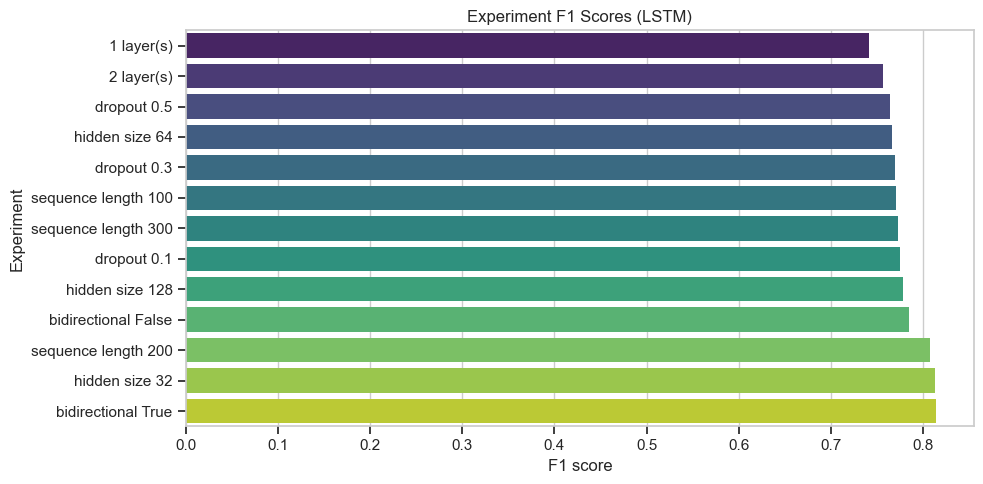

In [24]:
plt.figure(figsize=(10, 5))
plot_df = experiment_df.sort_values("f1", ascending=True)
sns.barplot(data=plot_df, x="f1", y="model", palette="viridis")
plt.title(f"Experiment F1 Scores ({BEST_MODEL_TYPE})")
plt.xlabel("F1 score")
plt.ylabel("Experiment")
plt.tight_layout()
plt.show()

# Discussion

Vanilla RNNs can forget early words when the review is long. This happens because gradients may become very small during backpropagation through many time steps.

LSTM and GRU models use gates. Gates decide what information should be kept, changed, or forgotten. Because of this, they can keep useful words from earlier parts of the review for a longer time.

LSTM has input, forget, and output gates. GRU has update and reset gates. Both help reduce the vanishing gradient problem and usually perform better than Vanilla RNN on long text sequences.